# Predicción del fútbol uruguayo: ID3 propio y Naive Bayes

En este notebook entrenamos dos clasificadores implementados a mano para
predecir si un partido de primera división lo gana el local (L), termina en
empate (E) o lo gana el visitante (V). Se usan partidos del campeonato
uruguayo y atributos basados solo en lo que pasó antes del partido.

El recorrido es: primero los datos y los atributos, después la forma de elegir
hiperparámetros con validación temporal, y recien al final la medición sobre el
test de 2024-2025. Las dos implementaciones propias estan en `id3.py` (árbol) y
`naive_bayes.py` (Naive Bayes), en la misma carpeta que este notebook. Todo el
pipeline que las alimenta (carga, limpieza, atributos causales,
discretización, folds y métricas) se define directamente en las celdas de este
notebook, para que sea autocontenido.

## 1. Configuración

Para que este notebook corra solo necesita, en la misma carpeta:

- `id3.py` y `naive_bayes.py` (los dos clasificadores propios,
  implementados a mano).
- `futbol_uruguayo.zip` (el dataset crudo), cuyo nombre y ubicacion se
  configuran en `RAW`: el ZIP debe estar junto al notebook. Si esta en otra
  ruta se ajusta esa variable y nada más.

Importamos las librerias de terceros (pandas, numpy, matplotlib y
scikit-learn, este último solo para medir y comparar) y los dos modelos
propios. Las funciones de datos, atributos, discretización, folds y métricas
se definen en las secciones 1.1 a 1.5.

In [1]:
import copy
import sys
from collections import defaultdict, deque
from dataclasses import dataclass, field
from pathlib import Path
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.naive_bayes import CategoricalNB
from sklearn.tree import DecisionTreeClassifier

# Los dos clasificadores propios viven en esta misma carpeta (id3.py y
# naive_bayes.py). El resto del pipeline se define en las proximas celdas.
sys.path.insert(0, str(Path.cwd()))

from id3 import ID3  # noqa: E402
from naive_bayes import MEstimateCategoricalNB  # noqa: E402

## El dataset crudo debe estar en la MISMA carpeta que este notebook, con el
## nombre futbol_uruguayo.zip. Si lo guardas en otra ruta, ajusta RAW acá.
RAW = Path('futbol_uruguayo.zip')
CLASSES = ['E', 'L', 'V']
RANDOM_STATE = 42
pd.set_option('display.max_columns', 30)


def entropia(series):
    """Entropía de Shannon en bits de una serie de etiquetas."""
    probs = series.value_counts(normalize=True)
    return float(-(probs * np.log2(probs)).sum())

### 1.1. Datos: carga y limpieza (definiciones)

El ZIP original se lee en memoria, se validan las columnas, se quitan los
partidos duplicados y los dudosos, y se descartan los definidos en alargue o
penales (su resultado no representa los 90 minutos). La clase `winner` se
deriva exclusivamente de los goles (`gh`, `ga`): `L` ganó el local, `V` ganó
el visitante, `E` empate. Los goles nunca son atributos del modelo: solo
sirven para la etiqueta y para los historiales de partidos anteriores.

In [2]:
_UNUSED_COLUMNS = {'away_code',
 'away_continent',
 'away_country',
 'away_ident',
 'competition',
 'continent',
 'home_code',
 'home_continent',
 'home_country',
 'home_ident',
 'level'}


def load_raw_matches(source):
    """Lee el ZIP original (un CSV) sin modificar los registros.

    gh/ga/winner se usan solo para construir la etiqueta y auditar. Nunca
    entran al modelo como atributos.
    """
    path = Path(source)
    with zipfile.ZipFile(path) as archive:
        csv_members = [
            name for name in archive.namelist() if name.lower().endswith(".csv")
        ]
        with archive.open(csv_members[0]) as stream:
            return pd.read_csv(stream, encoding="utf-8-sig")


def load_clean_matches(source):
    """Aplica la politica de auditoria antes de crear targets o historiales."""
    return _clean_matches(load_raw_matches(source))


def _normalize_matches(raw):
    """Limpieza mínima: nombres de columnas, tipos y goles enteros."""
    frame = raw.copy().reset_index(drop=True)
    frame.columns = [str(column).strip() for column in frame.columns]
    for column in frame.select_dtypes(include=["object", "string"]).columns:
        frame[column] = frame[column].astype("string").str.strip()
    frame["date"] = pd.to_datetime(frame["date"], format="%Y-%m-%d", errors="raise")
    frame["gh"] = pd.to_numeric(frame["gh"], errors="raise").astype("int64")
    frame["ga"] = pd.to_numeric(frame["ga"], errors="raise").astype("int64")
    return frame


def audit_match_records(raw):
    """Audita cada fila del CSV original (la línea 1 es el encabezado).

    Se mantienen el orden y los goles originales del archivador. Quedan en
    cuarentena todos los partidos duplicados exactos y los ambiguos (mismo par
    de equipos y misma fecha, sin importar el orden local/visitante), más los
    definidos en alargue o penales (full_time E o P). Que un equipo juegue dos
    veces el mismo día contra rivales distintos es solo una advertencia, no
    un duplicado.
    """
    frame = _normalize_matches(raw)
    exact_duplicate = frame.duplicated(keep="first")
    unique = frame.loc[~exact_duplicate]

    # Pares de equipos (sin importar el orden) por fecha: si hay más de un
    # partido con el mismo par, todos son ambiguos, no solo el segundo.
    pares = defaultdict(list)
    for indice, fila in unique.iterrows():
        pareja = tuple(sorted([str(fila["home"]), str(fila["away"])]))
        pares[(fila["date"], pareja)].append(indice)
    ambiguos = {
        indice
        for indices in pares.values()
        for indice in indices
        if len(indices) > 1
    }

    # Mismo equipo dos veces en la misma fecha contra rivales distintos.
    equipos = defaultdict(list)
    for indice, fila in unique.iterrows():
        for equipo in (str(fila["home"]), str(fila["away"])):
            equipos[(fila["date"], equipo)].append(indice)
    warnings = {
        indice
        for indices in equipos.values()
        for indice in indices
        if len(indices) > 1
    }

    audit = frame[["date", "home", "away", "gh", "ga", "full_time"]].copy()
    audit.insert(0, "source_line", frame.index + 2)
    audit["exact_duplicate"] = exact_duplicate
    audit["ambiguous_fixture"] = audit.index.isin(ambiguos)
    audit["extra_time_or_penalties"] = frame["full_time"].isin(["E", "P"])
    audit["team_date_warning"] = audit.index.isin(warnings)
    audit["included"] = ~audit[["exact_duplicate", "ambiguous_fixture",
                                "extra_time_or_penalties"]].any(axis=1)
    audit["reason"] = [
        ";".join(name for name in ("exact_duplicate", "ambiguous_fixture",
                                  "extra_time_or_penalties") if row[name])
        or "included"
        for _, row in audit.iterrows()
    ]
    return audit


def _clean_matches(raw):
    """Filtra la auditada y deriva winner antes de pasar a los atributos."""
    frame = _normalize_matches(raw)
    audit = audit_match_records(raw)
    frame = frame.loc[audit["included"]].copy()
    frame["winner"] = np.select(
        [frame["gh"] > frame["ga"], frame["gh"] < frame["ga"]],
        ["L", "V"],
        default="E",
    )
    frame["year"] = frame["date"].dt.year.astype("int64")
    frame["month"] = frame["date"].dt.month.astype("int64")
    frame = frame.sort_values(["date", "home", "away"], kind="stable").reset_index(
        drop=True
    )
    return frame.drop(columns=_UNUSED_COLUMNS.intersection(frame.columns))

### 1.2. Atributos causales (definiciones)

`build_causal_match_features` calcula, para cada partido, tasas históricas con
fechas estrictamente anteriores. El calculo de atributos procesa primero todos
los partidos de un mismo día y recien después actualiza los historiales, de
modo que un partido jamás usa el resultado de otro partido del mismo día (no
hay leakage). Si un equipo no tiene historial se imputa un neutro de `0.5` (no
`0.0`), para no confundir "nunca jugó" con "siempre perdió".

Sobre los mismos historiales se definen también `features_for_new_match` y
`predict_new_match`, que hacen el mismo calculo de atributos para un partido
hipotetico (usado en la sección 10.1).

In [3]:
CATEGORICAL_FEATURES = []


_ALL_COMPUTED_NUMERIC_FEATURES = ['home_prior_matches',
 'away_prior_matches',
 'home_win_rate_all',
 'away_win_rate_all',
 'home_win_rate_10y',
 'away_win_rate_10y',
 'home_win_rate_last_5',
 'away_win_rate_last_5',
 'home_win_rate_season',
 'away_win_rate_season',
 'home_win_rate_as_home_all',
 'home_win_rate_h2h_as_home',
 'home_points_per_match_5',
 'away_points_per_match_5',
 'home_goal_diff_per_match_5',
 'away_goal_diff_per_match_5',
 'win_rate_10y_diff',
 'form_points_diff',
 'form_goal_diff_diff']


NUMERIC_FEATURES = ['home_win_rate_last_5',
 'away_win_rate_last_5',
 'home_win_rate_season',
 'away_win_rate_season',
 'home_win_rate_as_home_all',
 'home_win_rate_h2h_as_home']


MODEL_FEATURES = ['home_win_rate_last_5',
 'away_win_rate_last_5',
 'home_win_rate_season',
 'away_win_rate_season',
 'home_win_rate_as_home_all',
 'home_win_rate_h2h_as_home']


NEUTRAL_WIN_RATE = 0.5
NEUTRAL_POINTS_PER_MATCH = 1.3333333333333333
NEUTRAL_GOAL_DIFF_PER_MATCH = 0.0


@dataclass
class _TeamState:
    matches: int = 0
    wins: int = 0
    last_ten_years: deque = field(default_factory=deque)
    last_five: deque = field(default_factory=lambda: deque(maxlen=5))
    last_five_wins: deque = field(default_factory=lambda: deque(maxlen=5))

    def snapshot(self, match_date):
        """Tasas hasta match_date. Los partidos de hace más de 10 años salen."""
        cutoff = match_date - pd.DateOffset(years=10)
        while self.last_ten_years and self.last_ten_years[0][0] < cutoff:
            self.last_ten_years.popleft()

        wins_10y = sum(win for _, win in self.last_ten_years)
        games_10y = len(self.last_ten_years)
        form_games = len(self.last_five)
        return {
            "prior_matches": float(self.matches),
            "win_rate_all": (
                self.wins / self.matches if self.matches else NEUTRAL_WIN_RATE
            ),
            "win_rate_10y": (
                wins_10y / games_10y if games_10y else NEUTRAL_WIN_RATE
            ),
            "win_rate_last_5": (
                sum(self.last_five_wins) / len(self.last_five_wins)
                if self.last_five_wins
                else NEUTRAL_WIN_RATE
            ),
            "points_per_match_5": (
                sum(points for points, _ in self.last_five) / form_games
                if form_games
                else NEUTRAL_POINTS_PER_MATCH
            ),
            "goal_diff_per_match_5": (
                sum(goal_difference for _, goal_difference in self.last_five)
                / form_games
                if form_games
                else NEUTRAL_GOAL_DIFF_PER_MATCH
            ),
        }

    def update(self, match_date, *, won, points, goals_for, goals_against):
        self.matches += 1
        self.wins += int(won)
        self.last_ten_years.append((match_date, int(won)))
        self.last_five.append((points, goals_for - goals_against))
        self.last_five_wins.append(int(won))


def build_causal_match_features(matches):
    """Devuelve una fila de modelado por partido usando solo fechas anteriores.

    Todos los partidos de la misma fecha se procesan antes de que sus
    resultados entren al historial de los equipos, así un partido jamás usa el
    resultado de otro partido del mismo día (no hay leakage). Durante la
    evaluación de 2024-2025 los resultados de fechas anteriores siguen
    disponibles, como en el uso real de prediccion online.
    """
    frame = matches.copy()
    frame["date"] = pd.to_datetime(frame["date"], errors="raise")
    frame = frame.sort_values(
        ["date", "home", "away"], kind="stable"
    ).reset_index(drop=True)

    histories = defaultdict(_TeamState)
    season_histories = defaultdict(lambda: [0, 0])
    home_histories = defaultdict(lambda: [0, 0])
    head_to_head_histories = defaultdict(lambda: [0, 0])
    feature_rows = []

    for match_date, same_day in frame.groupby("date", sort=True):
        pending_updates = []
        for _, match in same_day.iterrows():
            home_name = str(match["home"])
            away_name = str(match["away"])
            year = int(match_date.year)
            home = histories[home_name].snapshot(match_date)
            away = histories[away_name].snapshot(match_date)
            home_season_matches, home_season_wins = season_histories[(home_name, year)]
            away_season_matches, away_season_wins = season_histories[(away_name, year)]
            home_matches, home_wins = home_histories[home_name]
            h2h_matches, h2h_home_wins = head_to_head_histories[
                (home_name, away_name)
            ]
            feature_rows.append(
                {
                    "date": match_date,
                    "year": year,
                    "month": int(match_date.month),
                    "home": home_name,
                    "away": away_name,
                    "home_prior_matches": home["prior_matches"],
                    "away_prior_matches": away["prior_matches"],
                    "home_win_rate_all": home["win_rate_all"],
                    "away_win_rate_all": away["win_rate_all"],
                    "home_win_rate_10y": home["win_rate_10y"],
                    "away_win_rate_10y": away["win_rate_10y"],
                    "home_win_rate_last_5": home["win_rate_last_5"],
                    "away_win_rate_last_5": away["win_rate_last_5"],
                    "home_win_rate_season": (
                        home_season_wins / home_season_matches
                        if home_season_matches
                        else NEUTRAL_WIN_RATE
                    ),
                    "away_win_rate_season": (
                        away_season_wins / away_season_matches
                        if away_season_matches
                        else NEUTRAL_WIN_RATE
                    ),
                    "home_win_rate_as_home_all": (
                        home_wins / home_matches
                        if home_matches
                        else NEUTRAL_WIN_RATE
                    ),
                    "home_win_rate_h2h_as_home": (
                        h2h_home_wins / h2h_matches
                        if h2h_matches
                        else NEUTRAL_WIN_RATE
                    ),
                    "home_points_per_match_5": home["points_per_match_5"],
                    "away_points_per_match_5": away["points_per_match_5"],
                    "home_goal_diff_per_match_5": home["goal_diff_per_match_5"],
                    "away_goal_diff_per_match_5": away["goal_diff_per_match_5"],
                    "win_rate_10y_diff": home["win_rate_10y"] - away["win_rate_10y"],
                    "form_points_diff": home["points_per_match_5"]
                    - away["points_per_match_5"],
                    "form_goal_diff_diff": home["goal_diff_per_match_5"]
                    - away["goal_diff_per_match_5"],
                    "winner": str(match["winner"]),
                }
            )
            pending_updates.append(match)

        for match in pending_updates:
            winner = str(match["winner"])
            home_points = 3 if winner == "L" else 1 if winner == "E" else 0
            away_points = 3 if winner == "V" else 1 if winner == "E" else 0
            home_name = str(match["home"])
            away_name = str(match["away"])
            year = int(match_date.year)
            histories[home_name].update(
                match_date,
                won=winner == "L",
                points=home_points,
                goals_for=int(match["gh"]),
                goals_against=int(match["ga"]),
            )
            histories[away_name].update(
                match_date,
                won=winner == "V",
                points=away_points,
                goals_for=int(match["ga"]),
                goals_against=int(match["gh"]),
            )
            season_histories[(home_name, year)][0] += 1
            season_histories[(home_name, year)][1] += int(winner == "L")
            season_histories[(away_name, year)][0] += 1
            season_histories[(away_name, year)][1] += int(winner == "V")
            home_histories[home_name][0] += 1
            home_histories[home_name][1] += int(winner == "L")
            head_to_head_histories[(home_name, away_name)][0] += 1
            head_to_head_histories[(home_name, away_name)][1] += int(winner == "L")

    featured = pd.DataFrame(feature_rows)
    numeric_frame = featured[_ALL_COMPUTED_NUMERIC_FEATURES].to_numpy(dtype=float)
    if not np.isfinite(numeric_frame).all():
        raise ValueError("Los atributos numericos contienen valores no finitos.")
    return featured


def features_for_new_match(home_team, away_team, match_date, historical_df):
    """Atributos causales que tendria un partido hipotetico en match_date.

    historical_df debe ser el dataset con gh/ga/winner (no los atributos ya
    calculados). Solo se usan partidos con fecha anterior y el partido se
    procesa igual que cualquier otro en build_causal_match_features, así da
    exactamente los atributos que recibiria un partido real en esa fecha. Sin
    historial se imputan los neutros habituales (NEUTRAL_WIN_RATE = 0.5, etc.).
    """
    required = {"date", "home", "away", "gh", "ga", "winner"}
    match_date = pd.Timestamp(match_date)
    past = pd.to_datetime(historical_df["date"], errors="raise")
    history = historical_df.loc[past.lt(match_date), list(required)].copy()
    synthetic = pd.DataFrame([{
        "date": match_date,
        "home": str(home_team),
        "away": str(away_team),
        "gh": 0,
        "ga": 0,
        "winner": "E",
    }])
    frame = pd.concat([history, synthetic], ignore_index=True)
    featured = build_causal_match_features(frame)
    row = featured.loc[
        featured["date"].eq(match_date)
        & featured["home"].eq(str(home_team))
        & featured["away"].eq(str(away_team))
    ]
    if len(row) != 1:
        raise ValueError("No se pudieron calcular los atributos del partido hipotetico.")
    return row.iloc[0]


def predict_new_match(home_team, away_team, match_date, historical_df, model,
                      feature_columns=None, discretizer=None):
    """Predice un partido hipotetico con el mismo calculo de atributos de train.

    El modelo debe estar ya entrenado. feature_columns elige los atributos que
    espera el modelo. Usa NUMERIC_FEATURES para ID3, Naive Bayes o Random Forest
    y BASELINE_FEATURES para el clasificador base. Si se pasa discretizer
    (ajustado solo con train), los atributos se discretizan. Si no, se pasan
    las tasas crudas, como esperan el base y el random forest.
    """
    row = features_for_new_match(home_team, away_team, match_date, historical_df)
    if feature_columns is None:
        feature_columns = list(NUMERIC_FEATURES)
    input_frame = row[list(feature_columns)].to_frame().T
    X = discretizer.transform(input_frame) if discretizer is not None else input_frame

    classes = getattr(model, "classes_", [])
    predicted = str(model.predict(X)[0])
    result = {
        "features": {column: float(row[column]) for column in feature_columns},
        "prediccion": predicted,
        "probabilidades": None,
    }
    if hasattr(model, "predict_proba"):
        probabilities = model.predict_proba(X)[0]
        result["probabilidades"] = {
            str(class_label): float(value)
            for class_label, value in zip(classes, probabilities)
        }
    return result

### 1.3. Discretización (definición)

`MixedTypeDiscretizer` convierte cada tasa en una de tres categorías
(`baja`, `media`, `alta`), codificadas 1, 2, 3. El 0 queda para desconocidos.
Para `win_rate_last_5` usa cortes fijos `[0.3, 0.6]`. Para el resto, cuantiles
calculados solo con train (sin mirar validación ni test).

In [4]:
class MixedTypeDiscretizer:
    """Convierte tasas numericas en códigos (bins) y categorías en códigos.

    Las columnas numericas que no estan en ``fixed_cuts`` se parten con
    cuantiles (igual frecuencia) calculados en fit() sobre el train de cada
    fold. Las que figuran en ``fixed_cuts`` usan cortes fijos dados por el
    usuario, que no dependen de los datos, así que no introducen leakage y no
    requieren reajustarse. El valor 0 queda reservado para valores
    desconocidos o faltantes. Los numeros no finitos se imputan con la mediana
    del train (0 si la columna de train no tiene valores finitos).
    """

    def __init__(self, categorical_features, numeric_features, n_bins=5,
                 fixed_cuts=None):
        self.categorical_features = categorical_features
        self.numeric_features = numeric_features
        self.n_bins = n_bins
        self.fixed_cuts = fixed_cuts

    def fit(self, X, y=None):
        # Categorías: mapa {valor: código} en orden alfabetico. El 0 queda
        # reservado para valores que no se vieron en train.
        self.category_maps_ = {}
        for column in self.categorical_features:
            values = sorted(X[column].dropna().astype(str).unique())
            self.category_maps_[column] = {
                value: index + 1 for index, value in enumerate(values)
            }

        # Numerico: mediana del train (para imputar en transform) y bordes
        # de los bines. Los bordes de los cuantiles se calculan solo con train.
        self.numeric_medians_ = {}
        self.numeric_edges_ = {}
        quantiles = np.linspace(0.0, 1.0, self.n_bins + 1)[1:-1]
        for column in self.numeric_features:
            values = pd.to_numeric(X[column], errors="coerce").to_numpy(dtype=float)
            finite = values[np.isfinite(values)]
            self.numeric_medians_[column] = (
                float(np.median(finite)) if finite.size else 0.0
            )
            if self.fixed_cuts and column in self.fixed_cuts:
                self.numeric_edges_[column] = np.asarray(
                    self.fixed_cuts[column], dtype=float
                )
            else:
                self.numeric_edges_[column] = (
                    np.unique(np.quantile(finite, quantiles))
                    if finite.size
                    else np.asarray([], dtype=float)
                )
        return self

    def transform(self, X):
        columns = []
        for column in self.categorical_features:
            encoded = (
                X[column]
                .astype("string")
                .map(self.category_maps_[column])
                .fillna(0)
                .to_numpy(dtype=np.int64)
            )
            columns.append(encoded)

        for column in self.numeric_features:
            values = pd.to_numeric(X[column], errors="coerce").to_numpy(dtype=float)
            # La mediana es la de train y no cambia: nunca se aprende de
            # validación/test.
            values = np.where(
                np.isfinite(values), values, self.numeric_medians_[column]
            )
            encoded = np.digitize(values, self.numeric_edges_[column]) + 1
            columns.append(encoded.astype(np.int64))

        return np.column_stack(columns)

### 1.4. Partición temporal, folds y métricas (definiciones)

Los datos son series temporales y el uso real es predecir partidos futuros,
así que la partición es temporal y nunca aleatoria. `temporal_holdout` separa
train (hasta 2023) y test (2024-2025). `make_temporal_folds` arma los folds de
validación con los años completos 2021, 2022 y 2023 entrenando con lo anterior.
`evaluate_temporal_cv` recorre esos folds ajustando y prediciendo a mano en cada
uno (la validación es manual, sin pipelines de terceros). `reporte_por_clases`
imprime precision/recall/F1 por clase para cualquier modelo.

In [5]:
VALIDATION_YEARS = (2021, 2022, 2023)


LAST_5_CUTS = (0.3, 0.6)


@dataclass(frozen=True)
class TemporalFold:
    validation_year: int
    train_positions: tuple
    validation_positions: tuple


def _dates(frame):
    dates = pd.to_datetime(frame["date"], errors="raise")
    if dates.isna().any() or not dates.eq(dates.dt.normalize()).all():
        raise ValueError(
            "Se requieren fechas de partido completas, sin horas ni faltantes."
        )
    return dates


def make_temporal_folds(frame):
    """Entrenamiento expandido antes de cada año completo 2021, 2022 y 2023.

    Las posiciones refieren al frame recibido, sin importar su orden. Se
    rechaza el test 2024-2025 en lugar de dejarlo pasar por la CV.
    """
    dates = _dates(frame)
    if dates.dt.year.gt(2023).any():
        raise ValueError("La validación cruzada no acepta el test de 2024--2025.")
    folds = []
    for year in VALIDATION_YEARS:
        train = np.flatnonzero(dates.dt.year.lt(year).to_numpy())
        valid = np.flatnonzero(dates.dt.year.eq(year).to_numpy())
        if not len(train) or not len(valid):
            raise ValueError(f"El fold {year} necesita entrenamiento y validación.")
        folds.append(TemporalFold(year, tuple(map(int, train)), tuple(map(int, valid))))
    return tuple(folds)


def temporal_holdout(frame):
    dates = _dates(frame)
    if dates.dt.year.gt(2025).any():
        raise ValueError("Hay fechas posteriores al horizonte de la consigna.")
    train = frame.loc[dates.dt.year.le(2023)].reset_index(drop=True)
    test = frame.loc[dates.dt.year.between(2024, 2025)].reset_index(drop=True)
    if train.empty or test.empty:
        raise ValueError("Entrenamiento y evaluación deben contener partidos.")
    return train, test


def new_discretizer(feature_columns=None):
    """Devuelve un discretizador sin ajustar para cada particion de train."""
    return MixedTypeDiscretizer(
        categorical_features=[], numeric_features=(
            list(NUMERIC_FEATURES) if feature_columns is None else list(feature_columns)
        ),
        n_bins=3, fixed_cuts={column: LAST_5_CUTS for column in NUMERIC_FEATURES[:2]},
    )


def evaluate_temporal_cv(estimator, frame, folds, representation,
                         feature_columns=None):
    """Evalua solo cuando se la llama. Modelo nuevo y ajustado en cada fold.

    Se revalidan las posiciones contra el frame exacto para que ningun modelo
    use un split distinto. representation indica el tipo de input:
    "discrete" aplica la discretizacion ajustada por fold, "continuous" pasa
    las tasas crudas y "baseline" las tasas de diez anos sin discretizar.
    feature_columns permite comparar las entradas con el mismo preprocesado.
    """
    if folds != make_temporal_folds(frame):
        raise ValueError("Todos los modelos deben usar los folds anuales compartidos.")
    columns = list(NUMERIC_FEATURES if feature_columns is None else feature_columns)
    rows = []
    for fold in folds:
        train = frame.iloc[list(fold.train_positions)]
        valid = frame.iloc[list(fold.validation_positions)]

        if representation == "discrete":
            discretizer = new_discretizer(columns)
            discretizer.fit(train[columns])
            X_train = discretizer.transform(train[columns])
            X_valid = discretizer.transform(valid[columns])
        elif representation == "continuous":
            X_train = train[columns]
            X_valid = valid[columns]
        elif representation == "baseline":
            X_train = train[BASELINE_FEATURES]
            X_valid = valid[BASELINE_FEATURES]
        else:
            raise ValueError("Representacion desconocida: " + representation)

        model = copy.deepcopy(estimator)
        model.fit(X_train, train["winner"])
        prediction = model.predict(X_valid)
        train_prediction = model.predict(X_train)
        rows.append({
            "validacion": fold.validation_year,
            "n_train": len(train), "n_validacion": len(valid),
            "accuracy": accuracy_score(valid["winner"], prediction),
            "validation_error": 1.0 - accuracy_score(valid["winner"], prediction),
            "train_accuracy": accuracy_score(train["winner"], train_prediction),
            "train_error": 1.0 - accuracy_score(train["winner"], train_prediction),
            "train_macro_f1": f1_score(train["winner"], train_prediction,
                                       labels=list(CLASSES), average="macro",
                                       zero_division=0),
            "macro_f1": f1_score(valid["winner"], prediction,
                                 labels=list(CLASSES), average="macro",
                                 zero_division=0),
        })
    return pd.DataFrame(rows)


def reporte_por_clases(nombre, y_true, y_pred, digits=4):
    """Classification report por clase (precision, recall, F1, support).

    Se reusa para todos los modelos para que midan lo mismo en el mismo orden
    (E, L, V). zero_division=0 mantiene definida la tabla si una clase nunca
    se predice.
    """
    reporte = classification_report(
        y_true,
        y_pred,
        labels=list(CLASSES),
        target_names=list(CLASSES),
        digits=digits,
        zero_division=0,
    )
    print(f"### {nombre}\n{reporte}")
    return reporte

### 1.5. Clasificador base (definición)

Un clasificador fijo (sin aprendizaje) que compara las tasas de victoria de
los últimos diez años: gana el equipo con la tasa mayor. Los usuarios usan las
mismas tasas causales de 1.2. Sirve de piso para los modelos aprendidos.

In [6]:
BASELINE_FEATURES = ['home_win_rate_10y', 'away_win_rate_10y']


class TenYearWinRateClassifier:
    """Compara las tasas de victoria causales de los últimos diez años.

    predict compara las dos tasas: gana el equipo con la tasa mayor. Si son
    iguales, gana el local (a menos que se configure otro despliegue). Las
    tasas se calculan solo con partidos anteriores.
    """

    def __init__(self, tie_break="home"):
        self.tie_break = tie_break

    def fit(self, X, y):
        self.classes_ = np.unique(np.asarray(y))
        return self

    def predict(self, X):
        rates = X.loc[:, BASELINE_FEATURES].to_numpy(dtype=float)
        home, away = rates[:, 0], rates[:, 1]
        return np.where(home > away, "L", np.where(away > home, "V",
                        "L" if self.tie_break == "home" else "V"))

## 2. Datos: lectura y limpieza del ZIP

`load_clean_matches` extrae el ZIP original en memoria, normaliza las columnas,
quita partidos duplicados y dudosos, y deriva la clase `winner` exclusivamente
de los goles (`gh`, `ga`): `L` si ganó el local, `V` si ganó el visitante, `E`
si empataron. Los goles nunca son atributos del modelo: solo sirven para la
etiqueta y para los historiales de partidos anteriores.

In [7]:
matches = load_clean_matches(RAW)
print('Filas limpias:', len(matches))
display(matches.head(3))
display(matches.dtypes.to_frame(name='tipo'))
print('Distribución de la clase (todo el histórico):')
display(
    matches['winner']
    .value_counts()
    .reindex(CLASSES)
    .rename('cantidad')
    .to_frame()
)

# Auditoría del CSV crudo (mismos motivos que _clean_matches).
raw_df = load_raw_matches(RAW)
norm_df = _normalize_matches(raw_df)
audit_df = audit_match_records(raw_df)
print('Filas crudas:', raw_df.shape[0], '| columnas:', raw_df.shape[1])
print('Rango de fechas:', norm_df['date'].min().date(), '→',
      norm_df['date'].max().date())
print('Duplicado exacto:', int(audit_df['exact_duplicate'].sum()))
amb_df = audit_df[audit_df['ambiguous_fixture']].copy()
amb_df['pair'] = amb_df.apply(
    lambda r: tuple(sorted([str(r['home']), str(r['away'])])), axis=1)
n_grupos = amb_df.groupby(['date', 'pair']).ngroups
print('Grupos ambiguos (fecha + par sin orden):', n_grupos,
      '| filas ambiguas:', len(amb_df))
ep_df = audit_df[audit_df['extra_time_or_penalties']]
print('Prórroga (full_time E):', int((ep_df['full_time'] == 'E').sum()),
      '| Penales (full_time P):', int((ep_df['full_time'] == 'P').sum()))
print('Advertencias de equipo/fecha admitidas:',
      int((audit_df['team_date_warning'] & audit_df['included']).sum()))
print('Excluidas en total:', int((~audit_df['included']).sum()))

Filas limpias: 15177


,home,away,date,gh,ga,full_time,winner,year,month
0,Bella Vista,Defensor Sporting,1932-03-05,1,2,F,V,1932,3
1,CA Penarol,River Plate,1932-03-05,1,1,F,E,1932,3
2,Central Espanol,Rampla Juniors Futbol Club,1932-03-05,1,0,F,L,1932,3


,tipo
home,string[python]
away,string[python]
date,datetime64[ns]
gh,int64
ga,int64
full_time,string[python]
winner,object
year,int64
month,int64


Distribución de la clase (todo el histórico):


,cantidad
winner,
E,4160
L,6735
V,4282


Filas crudas: 15207 | columnas: 17
Rango de fechas: 1932-03-05 → 2025-06-30
Duplicado exacto: 1
Grupos ambiguos (fecha + par sin orden): 7 | filas ambiguas: 16
Prórroga (full_time E): 5 | Penales (full_time P): 8
Advertencias de equipo/fecha admitidas: 175
Excluidas en total: 30


## 3. Atributos causales

`build_causal_match_features` calcula, para cada partido, tasas históricas con
fechas estrictamente anteriores. El calculo de atributos procesa primero todos
los partidos de un mismo día y recien después actualiza los historiales, de
modo que un partido jamás usa el resultado de otro partido del mismo día (no
hay leakage).

Se usan seis tasas de victoria que cubren horizontes distintos:

- `home/away_win_rate_last_5`: forma reciente de cada equipo (5 partidos).
- `home/away_win_rate_season`: éxito dentro del año calendario.
- `home_win_rate_as_home_all`: histórico del local cuando juega de local.
- `home_win_rate_h2h_as_home`: histórico del local contra ese rival.

Con eso el modelo puede usar tanto el momento de forma actual como el
desempeño de largo plazo (localia y duelo directo). Los nombres de los equipos
y el mes no entran como atributos: son identificadores que no generalizan y
provocarian sobreajuste.

Si un equipo no tiene historial se imputa un neutro de `0.5` (no `0.0`), para
no confundir "nunca jugó" con "siempre perdió".

In [8]:
featured = build_causal_match_features(matches)
print('Partidos con atributos:', len(featured))
display(featured[['date', 'home', 'away'] + NUMERIC_FEATURES + ['winner']].head(5))

sin_historial = featured[featured['home_win_rate_season'].eq(0.5)]
print('Ejemplos con tasa 0.5 (neutro imputado o tasa real):')
display(sin_historial[['date', 'home', 'away'] + NUMERIC_FEATURES].head(3))

Partidos con atributos: 15177


,date,home,away,home_win_rate_last_5,away_win_rate_last_5,home_win_rate_season,away_win_rate_season,home_win_rate_as_home_all,home_win_rate_h2h_as_home,winner
0,1932-03-05,Bella Vista,Defensor Sporting,0.5,0.5,0.5,0.5,0.5,0.5,V
1,1932-03-05,CA Penarol,River Plate,0.5,0.5,0.5,0.5,0.5,0.5,E
2,1932-03-05,Central Espanol,Rampla Juniors Futbol Club,0.5,0.5,0.5,0.5,0.5,0.5,L
3,1932-03-05,Montevideo Wanderers,Racing Club,0.5,0.5,0.5,0.5,0.5,0.5,L
4,1932-03-05,Nacional,Institucion Atletica Sud America,0.5,0.5,0.5,0.5,0.5,0.5,L


Ejemplos con tasa 0.5 (neutro imputado o tasa real):


,date,home,away,home_win_rate_last_5,away_win_rate_last_5,home_win_rate_season,away_win_rate_season,home_win_rate_as_home_all,home_win_rate_h2h_as_home
0,1932-03-05,Bella Vista,Defensor Sporting,0.5,0.5,0.5,0.5,0.5,0.5
1,1932-03-05,CA Penarol,River Plate,0.5,0.5,0.5,0.5,0.5,0.5
2,1932-03-05,Central Espanol,Rampla Juniors Futbol Club,0.5,0.5,0.5,0.5,0.5,0.5


## 4. Partición temporal y folds

Los datos son series temporales y el uso real es predecir partidos futuros,
así que la partición es temporal y nunca aleatoria (una partición aleatoria
filtraría información del futuro hacia el entrenamiento):

- Train: partidos hasta 2023 inclusive.
- Test: partidos de 2024 y 2025 (queda reservado para la medición final).

Para elegir hiperparámetros se usan los años completos 2021, 2022 y 2023 como
validación, entrenando en cada fold con todos los partidos anteriores a ese
año. El test no participa en ninguna decisión.

In [9]:
train, test = temporal_holdout(featured)
assert train['date'].dt.year.le(2023).all()
assert test['date'].dt.year.isin([2024, 2025]).all()
print('Train:', len(train), 'partidos (hasta 2023)')
print('Test: ', len(test), 'partidos (2024-2025)')

print('Distribución de clases en train:')
display(train['winner'].value_counts(normalize=True).reindex(CLASSES))
print('Distribución de clases en test:')
display(test['winner'].value_counts(normalize=True).reindex(CLASSES))

folds = make_temporal_folds(train)
display(pd.DataFrame([
    {'validación': fold.validation_year,
     'train_hasta': train.iloc[list(fold.train_positions)]['date'].max().date(),
     'validacion_desde': train.iloc[list(fold.validation_positions)]['date'].min().date(),
     'validacion_hasta': train.iloc[list(fold.validation_positions)]['date'].max().date(),
     'n_train': len(fold.train_positions),
     'n_validacion': len(fold.validation_positions)}
    for fold in folds
]))

Train: 14705 partidos (hasta 2023)
Test:  472 partidos (2024-2025)
Distribución de clases en train:


winner
E    0.273988
L    0.445087
V    0.280925
Name: proportion, dtype: float64

Distribución de clases en test:


winner
E    0.277542
L    0.402542
V    0.319915
Name: proportion, dtype: float64

,validación,train_hasta,validacion_desde,validacion_hasta,n_train,n_validacion
0,2021,2020-12-19,2021-01-13,2021-12-06,13744,364
1,2022,2021-12-06,2022-02-05,2022-10-24,14108,297
2,2023,2022-10-24,2023-02-04,2023-12-16,14405,300


## 5. Discretización

ID3 y Naive Bayes categorico trabajan con enteros. Cada tasa se convierte en
una de tres categorías (`baja`, `media`, `alta`), codificadas 1, 2, 3 (el 0
queda reservado para valores desconocidos).

Dos estrategias de cortes:

- `win_rate_last_5`: cortes fijos `[0.3, 0.6]`. Como la tasa solo toma valores
  de 0.2 en 0.2, significan 0-1 triunfos, 2 triunfos, 3+ triunfos de los
  últimos 5. No dependen de los datos y no requieren ajustarse con train.
- El resto: cuantiles (equal-frequency) calculados solo con train.

In [10]:
discretizer = new_discretizer()
discretizer.fit(train[NUMERIC_FEATURES])

print('Bordes de cada atributo (dos cortes -> tres bines):')
display(
    pd.DataFrame(
        {column: discretizer.numeric_edges_[column] for column in NUMERIC_FEATURES}
    ).T.rename(columns={0: 'borde_1', 1: 'borde_2'})
)

X_train = discretizer.transform(train[NUMERIC_FEATURES])
X_test = discretizer.transform(test[NUMERIC_FEATURES])

print('Ejemplo: la tasa cruda y el código que recibe el modelo:')
muestra = train[['home', 'away'] + NUMERIC_FEATURES].head(5).copy()
codigos = pd.DataFrame(
    X_train[:5], columns=[column + '_cod' for column in NUMERIC_FEATURES]
)
display(pd.concat([muestra, codigos], axis=1))

print('Filas de train por categoría:')
resumen = pd.DataFrame({column: pd.Series(X_train[:, i]).map(
    {1: 'baja', 2: 'media', 3: 'alta'}
).value_counts() for i, column in enumerate(NUMERIC_FEATURES)})
display(resumen.reindex(['baja', 'media', 'alta']).fillna(0).astype(int))

Bordes de cada atributo (dos cortes -> tres bines):


,borde_1,borde_2
home_win_rate_last_5,0.300000,0.600000
away_win_rate_last_5,0.300000,0.600000
home_win_rate_season,0.250000,0.454545
away_win_rate_season,0.269231,0.466667
home_win_rate_as_home_all,0.409916,0.478353
home_win_rate_h2h_as_home,0.375000,0.555556


Ejemplo: la tasa cruda y el código que recibe el modelo:


,home,away,home_win_rate_last_5,away_win_rate_last_5,home_win_rate_season,away_win_rate_season,home_win_rate_as_home_all,home_win_rate_h2h_as_home,home_win_rate_last_5_cod,away_win_rate_last_5_cod,home_win_rate_season_cod,away_win_rate_season_cod,home_win_rate_as_home_all_cod,home_win_rate_h2h_as_home_cod
0,Bella Vista,Defensor Sporting,0.5,0.5,0.5,0.5,0.5,0.5,2,2,3,3,3,2
1,CA Penarol,River Plate,0.5,0.5,0.5,0.5,0.5,0.5,2,2,3,3,3,2
2,Central Espanol,Rampla Juniors Futbol Club,0.5,0.5,0.5,0.5,0.5,0.5,2,2,3,3,3,2
3,Montevideo Wanderers,Racing Club,0.5,0.5,0.5,0.5,0.5,0.5,2,2,3,3,3,2
4,Nacional,Institucion Atletica Sud America,0.5,0.5,0.5,0.5,0.5,0.5,2,2,3,3,3,2


Filas de train por categoría:


,home_win_rate_last_5,away_win_rate_last_5,home_win_rate_season,away_win_rate_season,home_win_rate_as_home_all,home_win_rate_h2h_as_home
baja,6429,6398,4311,4886,4902,4792
media,4243,4238,5432,4869,4901,5000
alta,4033,4069,4962,4950,4902,4913


## 6. Cómo decide el árbol: entropía y ganancia

ID3 elige el atributo que más reduce la entropia (desorden) de la clase. La
entropia se mide en bits:

```text
H(Y) = -sum_c P(c) * log2(P(c))
```

La ganancia de información de un atributo es la entropia menos la entropia
condicional promedio tras partir por ese atributo. Acá calculamos la primera
división que haria el árbol sobre todo el train.

In [11]:
parent_entropy = entropia(train['winner'])
print(f'Entropía de la clase en train: {parent_entropy:.4f} bits '
      '(máximo teórico ~1.585 para 3 clases equiprobables)')

gains = []
for index, column in enumerate(NUMERIC_FEATURES):
    conditional = 0.0
    for codigo in np.unique(X_train[:, index]):
        mask = X_train[:, index] == codigo
        conditional += mask.mean() * entropia(train['winner'][mask])
    gains.append({
        'atributo': column,
        'entropia_condicional': round(conditional, 4),
        'ganancia': round(parent_entropy - conditional, 4),
    })
gains_frame = pd.DataFrame(gains).sort_values('ganancia', ascending=False)
display(gains_frame.reset_index(drop=True))

mejor = gains_frame.iloc[0]
print(f'Primera división sobre {mejor["atributo"]} '
      f'(ganancia {mejor["ganancia"]:.4f} bits).')

Entropía de la clase en train: 1.5461 bits (máximo teórico ~1.585 para 3 clases equiprobables)


,atributo,entropia_condicional,ganancia
0,home_win_rate_h2h_as_home,1.5040,0.0422
1,home_win_rate_as_home_all,1.5136,0.0325
2,home_win_rate_season,1.5218,0.0243
3,away_win_rate_last_5,1.5258,0.0203
4,away_win_rate_season,1.5275,0.0187
5,home_win_rate_last_5,1.5325,0.0136


Primera división sobre home_win_rate_h2h_as_home (ganancia 0.0422 bits).


## 7. Cómo se miden los resultados

Definimos acá, brevemente, las medidas que usamos de aquí en adelante.

**Accuracy** (exactitud): fracción de partidos bien clasificados sobre el total.
Es fácil de entender pero sola engana cuando hay clases desbalanceadas: acá,
predecir siempre L ya rondaria el 40% (L es la clase más comun).

Para el resto pensamos clase por clase. Con tres clases, para cada una (por
ejemplo L) separamos las predicciones en:

- **true positives (TP)**: partidos que eran L y se predijeron L.
- **false positives (FP)**: partidos que no eran L pero se predijeron L.
- **false negatives (FN)**: partidos que eran L y se predijeron otra cosa.

Y se definen:

- **Precision**: TP / (TP + FP). De lo que el modelo predijo como L, que
  fracción era L en realidad.
- **Recall**: TP / (TP + FN). De los L que había, cuántos atrapó.
- **F1-score**: media armónica de precision y recall, `2PR/(P+R)`.
- **Support**: cuántos ejemplos reales de esa clase había.

Como hay tres clases, los promedios se hacen de dos formas:

- **macro** (simple): las tres clases pesan igual. Es estricto con la clase
  chica (el empate).
- **weighted** (ponderado): pesa cada clase según su support. Refleja el
  dataset real pero puede esconder que una clase chica rinde mal.

El **macro-F1** es el promedio macro del F1 y es el criterio que usamos para
elegir hiperparámetros: con accuracy, un modelo que nunca predice empates
pareceria aceptable. El **error** es `1 - accuracy`, la fracción de partidos
equivocados, y es lo que graficamos como "error de validación".

## 8. ID3: elegir la poda con validación

El único hiperparámetro de nuestro ID3 es `min_info_gain`: se corta la
expansion cuando la mejor ganancia de información disponible es menor o igual
que ese umbral. Sin poda el árbol crece hasta memorizar ruido del train. El
umbral controla que tan fino sigue creciendo.

Para elegirlo barremos una grilla y medimos con la validación temporal:

- **error_validacion** = `1 - accuracy` y **macro_f1** (sección 7): cada fila
  es la media sobre los tres folds.
- Las columnas `*_std` son la desviación estándar entre esos tres folds. La
  reportamos porque la media sola no alcanza: una desviación chica indica que
  el resultado se mantiene entre temporadas y no depende de un solo año.
- **error_train** es el error sobre el train de cada fold, como control de
  sobreajuste: si es mucho menor que el de validación, el árbol memorizo datos
  de train que no generalizan.

Elegimos el umbral que maximiza el **macro-F1** de validación (da el mismo peso
a E, L y V. Con accuracy un árbol que solo predice L quedaria bien ranqueado).
Como desempate, ante valores iguales tomamos el umbral menor: podamos solo
cuando la validación lo justifica. En la tabla el pico es claro, `0.005`:
después el macro-F1 no mejora.

,min_info_gain,error_validacion,error_validacion_std,macro_f1,macro_f1_std,error_train,profundidad,hojas
0,0.000,0.579693,0.011718,0.380579,0.013749,0.472063,6,644
1,0.001,0.578777,0.013009,0.381234,0.014674,0.472063,6,644
2,0.005,0.576739,0.013472,0.381798,0.016158,0.473186,6,589
3,0.010,0.571926,0.014512,0.363435,0.014855,0.483426,6,385
4,0.020,0.606651,0.018991,0.277046,0.003232,0.513098,2,7
5,0.050,0.622437,0.016271,0.182653,0.005727,0.552045,0,1


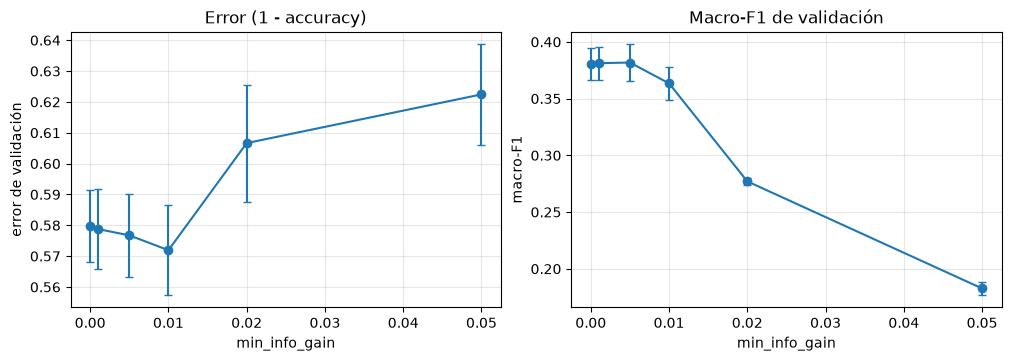

min_info_gain elegido: 0.005
Con ese umbral el árbol tiene profundidad 6 y 589 hojas


In [12]:
grid_gain = [0.0, 0.001, 0.005, 0.01, 0.02, 0.05]
filas_id3 = []
for ganancia in grid_gain:
    detalle = evaluate_temporal_cv(
        ID3(min_info_gain=ganancia), train, folds, 'discrete'
    )
    arbol_tmp = ID3(min_info_gain=ganancia).fit(X_train, train['winner'])
    filas_id3.append({
        'min_info_gain': ganancia,
        'error_validacion': detalle.validation_error.mean(),
        'error_validacion_std': detalle.validation_error.std(ddof=0),
        'macro_f1': detalle.macro_f1.mean(),
        'macro_f1_std': detalle.macro_f1.std(ddof=0),
        'error_train': detalle.train_error.mean(),
        'profundidad': arbol_tmp.get_depth(),
        'hojas': arbol_tmp.get_n_leaves(),
    })
cv_id3 = pd.DataFrame(filas_id3)
display(cv_id3.round(6))

fig, ejes = plt.subplots(1, 2, figsize=(10, 3.5), layout='constrained')
ejes[0].errorbar(cv_id3['min_info_gain'], cv_id3['error_validacion'],
                 yerr=cv_id3['error_validacion_std'], marker='o', capsize=3)
ejes[0].set(xlabel='min_info_gain', ylabel='error de validación',
            title='Error (1 - accuracy)')
ejes[1].errorbar(cv_id3['min_info_gain'], cv_id3['macro_f1'],
                 yerr=cv_id3['macro_f1_std'], marker='o', capsize=3)
ejes[1].set(xlabel='min_info_gain', ylabel='macro-F1',
            title='Macro-F1 de validación')
for eje in ejes:
    eje.grid(alpha=0.3)
plt.show()

id3_gain = float(
    cv_id3.sort_values(['macro_f1', 'min_info_gain'],
                       ascending=[False, True]).iloc[0]['min_info_gain']
)
fila_elegida = cv_id3[cv_id3['min_info_gain'] == id3_gain].iloc[0]
print('min_info_gain elegido:', id3_gain)
print(f'Con ese umbral el árbol tiene profundidad {fila_elegida["profundidad"]:.0f} '
      f'y {fila_elegida["hojas"]:.0f} hojas')

Vemos la misma medición de dos formas. El error de validación (1 - accuracy)
baja hasta `min_info_gain = 0.01` y después sube. El macro-F1 tiene su máximo en
`0.005` y cae desde `0.01`. Elegimos por macro-F1 porque no queremos un árbol que
ignore las clases minoritarias. Entre `0.0` y `0.005` la diferencia de macro-F1
(≈0.001) es mucho menor que la desviación entre folds (≈0.015), así que esos
valores no se distinguen con estos datos. `0.005` es el máximo nominal, y además
poda algo (589 hojas contra 644). A partir de `0.02` el árbol queda demasiado
podado y el rendimiento cae fuerte.

## 9. ID3: entrenar y medir sobre el test

Con el umbral elegido entrenamos el árbol con todo el train y lo evaluamos por
primera vez sobre 2024-2025. `classification_report` da, para cada clase,
**precision**, **recall**, **F1** y **support**, y dos promedios (macro y
weighted). La **matriz de confusion** los muestra por clase: filas = real,
columnas = predicho. También reportamos la importancia de cada atributo
(ganancia acumulada normalizada) para ver que usa el árbol.

Accuracy: 0.4661
Macro-F1: 0.4027
Profundidad: 6 | hojas: 589
### ID3 propio
              precision    recall  f1-score   support

           E     0.3214    0.1374    0.1925       131
           L     0.4757    0.7737    0.5892       190
           V     0.5140    0.3642    0.4264       151

    accuracy                         0.4661       472
   macro avg     0.4371    0.4251    0.4027       472
weighted avg     0.4452    0.4661    0.4270       472



,atributo,importancia
5,home_win_rate_h2h_as_home,0.274266
0,home_win_rate_last_5,0.178353
2,home_win_rate_season,0.163432
1,away_win_rate_last_5,0.155606
3,away_win_rate_season,0.131259
4,home_win_rate_as_home_all,0.097084


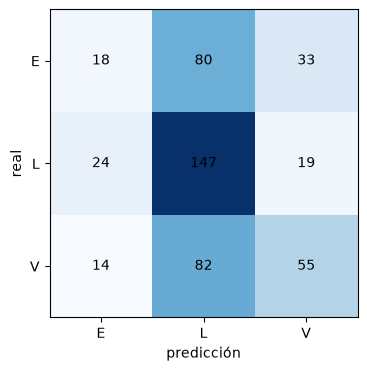

In [13]:
arbol_id3 = ID3(min_info_gain=id3_gain)
arbol_id3.fit(X_train, train['winner'])

y_test = test['winner'].to_numpy()
y_pred = arbol_id3.predict(X_test)

print('Accuracy:', round(accuracy_score(y_test, y_pred), 4))
print('Macro-F1:', round(
    f1_score(y_test, y_pred, average='macro', zero_division=0), 4))
print('Profundidad:', arbol_id3.get_depth(), '| hojas:', arbol_id3.get_n_leaves())
reporte_por_clases('ID3 propio', y_test, y_pred)

importancias = pd.DataFrame({
    'atributo': NUMERIC_FEATURES,
    'importancia': arbol_id3.feature_importances_,
}).sort_values('importancia', ascending=False)
display(importancias)

matriz = confusion_matrix(y_test, y_pred, labels=CLASSES)
fig, axis = plt.subplots(figsize=(4.5, 4))
axis.imshow(matriz, cmap='Blues')
axis.set(xticks=range(3), xticklabels=CLASSES,
         yticks=range(3), yticklabels=CLASSES,
         xlabel='predicción', ylabel='real')
for fila in range(3):
        for col in range(3):
            axis.text(col, fila, str(matriz[fila, col]),
                      ha='center', va='center')
plt.show()

La diagonal son los aciertos. El árbol predice L el 65% de las veces (309 de 472), casi el doble de lo que L realmente ocurre (40%). Por eso acierta mucho en L (147 de 190, 77% de recall) pero pierde casi todos los empates (18 de 131, 14%) y buena parte de las victorias visitantes (55 de 151, 36%). El accuracy (0.4661) queda alto porque pondera por la cantidad de casos y L es la clase más grande y mejor predicha, mientras que el macro-F1 (0.4027) cae porque promedia las 3 clases por igual, sin premiar que L tenga más casos, y ahí pesa el mal desempeño en E y V.

## 10. Ejemplos: donde acierta y donde falla

Vemos partidos reales de test con la predicción. La columna `acierta` indica
si el árbol acerto. Los empates son la clase que más se pierde.

In [14]:
predicciones = test[['date', 'home', 'away', 'winner']].copy()
predicciones['prediccion_id3'] = y_pred
predicciones['acierta'] = predicciones['prediccion_id3'] == predicciones['winner']
display(predicciones.sample(8, random_state=RANDOM_STATE))
print('Aciertos totales:', int(predicciones['acierta'].sum()), '/', len(predicciones))

empates_reales = predicciones[predicciones['winner'] == 'E']
print('Sobre los', len(empates_reales), 'empates reales del test, '
      f'ID3 predijo empate en '
      f'{(empates_reales["prediccion_id3"] == "E").sum()} '
      f'({(empates_reales["prediccion_id3"] == "E").mean():.1%}).')
display(empates_reales.head(3))

,date,home,away,winner,prediccion_id3,acierta
55,2024-04-13,CA Cerro,CA Fenix,E,L,False
73,2024-04-27,Rampla Juniors Futbol Club,Deportivo Maldonado,E,L,False
33,2024-03-23,Nacional,CA Progreso,E,L,False
278,2024-11-18,CA Progreso,CA Fenix,E,V,False
244,2024-10-20,Cerro Largo FC,Danubio,E,L,False
380,2025-04-13,Boston River,Cerro Largo FC,L,L,True
211,2024-09-29,Defensor Sporting,Deportivo Maldonado,L,L,True
9,2024-02-24,Montevideo Wanderers,Racing Club,V,E,False


Aciertos totales: 220 / 472
Sobre los 131 empates reales del test, ID3 predijo empate en 18 (13.7%).


,date,home,away,winner,prediccion_id3,acierta
3,2024-02-18,CA Cerro,Montevideo Wanderers,E,L,False
5,2024-02-18,Racing Club,Liverpool,E,V,False
8,2024-02-24,Boston River,Danubio,E,L,False


### 10.1. Predicción de un partido nuevo

Para demostrar que un modelo entrenado sirve para clasificar una instancia
nueva, `predict_new_match` (definida mas arriba en este notebook) aplica a un partido
hipotetico exactamente el mismo calculo de atributos del resto del notebook:
solo partidos anteriores, los mismos calculos y la misma imputación neutra si
no hay historial. No se reimplementan tasas ni se le pasa ningun resultado.

Tomamos tres partidos futuros (no estan en el dataset) y los clasificamos con
dos modelos ya entrenados: el ID3 propio (discretizado) y el clasificador base
(tasas crudas). No buscamos optimizar nada, solo mostrar el uso.

In [15]:

base_demo = TenYearWinRateClassifier().fit(
    train[BASELINE_FEATURES], train['winner'])

partidos_nuevos = [
    ('Nacional', 'CA Penarol', '2025-11-16'),
    ('Boston River', 'Torque FC', '2025-11-16'),
    ('CA Juventud', 'Plaza Colonia', '2025-11-16'),
]

filas_demo = []
for home, away, fecha in partidos_nuevos:
    id3_demo = predict_new_match(
        home, away, fecha, matches, arbol_id3,
        feature_columns=NUMERIC_FEATURES, discretizer=discretizer)
    base_demo_pred = predict_new_match(
        home, away, fecha, matches, base_demo,
        feature_columns=BASELINE_FEATURES, discretizer=None)
    filas_demo.append({
        'fecha': fecha,
        'partido': f'{home} vs {away}',
        'forma local': round(id3_demo['features']['home_win_rate_last_5'], 2),
        'forma visitante': round(id3_demo['features']['away_win_rate_last_5'], 2),
        'h2h local': round(id3_demo['features']['home_win_rate_h2h_as_home'], 2),
        'ID3': id3_demo['prediccion'],
        'Base 10 años': base_demo_pred['prediccion'],
    })
display(pd.DataFrame(filas_demo))


,fecha,partido,forma local,forma visitante,h2h local,ID3,Base 10 años
0,2025-11-16,Nacional vs CA Penarol,1.0,0.8,0.41,L,L
1,2025-11-16,Boston River vs Torque FC,0.2,0.2,0.43,L,L
2,2025-11-16,CA Juventud vs Plaza Colonia,0.8,0.2,0.17,V,V


## 11. Comparadores

Comparamos el ID3 propio con:

- `sklearn DecisionTree` con el mismo input discretizado: sirve para comparar
  nuestra implementación con la de la biblioteca, con el mismo input para las
  dos.
- `sklearn DecisionTree` con las tasas crudas: puede cortar en cualquier
  umbral, muestra cuanto gana un árbol sobre el input continuo.
- `sklearn RandomForest` (300 árboles, `class_weight='balanced_subsample'`):
  el bosque da más peso a las clases chicas en cada árbol para no ignorar el
  empate. Es una referencia alta, no una competencia directa.
- El clasificador base: gana el equipo con mayor proporción de victorias en
  los últimos diez años (una regla fija, sin aprendizaje).

Todos se entrenan solo con train y se evalúan sobre el mismo test de
2024-2025. La tabla compara accuracy y macro-F1 (sección 7).

In [16]:
X_train_raw = train[NUMERIC_FEATURES].to_numpy()
X_test_raw = test[NUMERIC_FEATURES].to_numpy()
y_train = train['winner'].to_numpy()

competidores = {
    'sklearn DT (mismo input)': DecisionTreeClassifier(criterion='entropy', random_state=RANDOM_STATE),
    'sklearn DT (tasas crudas)': DecisionTreeClassifier(criterion='entropy', random_state=RANDOM_STATE),
    'sklearn RandomForest (tasas crudas)': RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=20,
        class_weight='balanced_subsample',
        random_state=RANDOM_STATE,
    ),
}

filas_comp = []
predicciones_comp = {}
for nombre, modelo in competidores.items():
    usa_codigos = 'mismo input' in nombre
    X_entrena = X_train if usa_codigos else X_train_raw
    X_prueba = X_test if usa_codigos else X_test_raw
    modelo.fit(X_entrena, y_train)
    predicha = modelo.predict(X_prueba)
    predicciones_comp[nombre] = predicha
    filas_comp.append({
        'modelo': nombre,
        'accuracy': round(accuracy_score(y_test, predicha), 4),
        'macro_f1': round(
            f1_score(y_test, predicha, average='macro', zero_division=0), 4),
    })

base_10 = TenYearWinRateClassifier()
base_10.fit(train[BASELINE_FEATURES], train['winner'])
pred_base = base_10.predict(test[BASELINE_FEATURES])
filas_comp.append({
    'modelo': 'Base 10 años (clasificador base)',
    'accuracy': round(accuracy_score(y_test, pred_base), 4),
    'macro_f1': round(
        f1_score(y_test, pred_base, average='macro', zero_division=0), 4),
})
filas_comp.append({
    'modelo': 'ID3 propio',
    'accuracy': round(accuracy_score(y_test, y_pred), 4),
    'macro_f1': round(
        f1_score(y_test, y_pred, average='macro', zero_division=0), 4),
})
display(pd.DataFrame(filas_comp))

,modelo,accuracy,macro_f1
0,sklearn DT (mismo input),0.4682,0.4109
1,sklearn DT (tasas crudas),0.3602,0.3531
2,sklearn RandomForest (tasas crudas),0.4258,0.4219
3,Base 10 años (clasificador base),0.4619,0.3564
4,ID3 propio,0.4661,0.4027


## 12. Naive Bayes propio

Naive Bayes combina la frecuencia de cada clase con la de sus atributos,
asumiendo independencia entre atributos dada la clase. Nuestra implementación
(`MEstimateCategoricalNB`) usa suavizado m-estimate:

$$
P(X_j = v \mid Y = c) = \frac{n_{jvc} + m \cdot p_{jv}}{n_c + m}
$$

con un prior uniforme de categorías `p_jv = 1 / K_j` (K_j = 4: tres bines más
el 0 reservado). `m` agrega conteos artificiales y evita probabilidades
cero. Cuanto mayor es `m`, más se acerca a un prior uniforme y menos pesa la
frecuencia observada.

`CategoricalNB` de scikit-learn estima `(n + alpha) / (n_c + alpha * K)`, que
coincide con la nuestra tomando `alpha = m / 4`. Por eso barremos `m` sobre la
validación y repetimos la grilla con `CategoricalNB(m/4)`, confirmando la
equivalencia problema a problema.

Elegimos el `m` que maximiza el macro-F1 de validación, con el mismo desempate
que en ID3: ante valores que rinden igual, el menor `m` (no agregamos
suavizado artificial del que los datos no dan evidencia). Las columnas `*_std`
son la desviación estándar entre los tres folds y `error_validacion` es
`1 - accuracy` (sección 7).

,m,alpha,error_validacion,error_validacion_std,macro_f1,macro_f1_sklearn,macro_f1_std
0,0.1,0.025,0.565633,0.035400,0.363482,0.363482,0.032202
1,1.0,0.250,0.565633,0.035400,0.363482,0.363482,0.032202
2,10.0,2.500,0.565633,0.035400,0.363482,0.363482,0.032202
3,100.0,25.000,0.567146,0.038048,0.358941,0.358941,0.033387
4,1000.0,250.000,0.566571,0.029783,0.334176,0.334176,0.022262


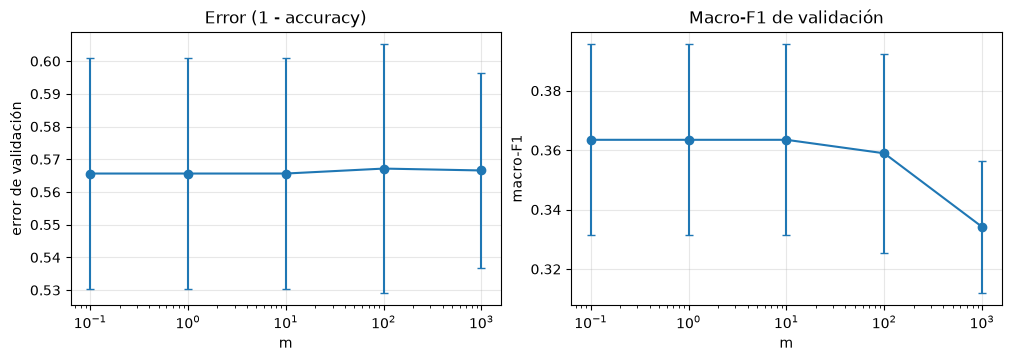

m elegido: 0.1 -> alpha = 0.025


In [17]:
grid_m = [0.1, 1, 10, 100, 1000]
filas_nb = []
for m in grid_m:
    propio = evaluate_temporal_cv(
        MEstimateCategoricalNB(m=m, min_categories=4), train, folds, 'discrete')
    referencia = evaluate_temporal_cv(
        CategoricalNB(alpha=m / 4, min_categories=4, force_alpha=True),
        train, folds, 'discrete')
    filas_nb.append({
        'm': m,
        'alpha': m / 4,
        'error_validacion': propio.validation_error.mean(),
        'error_validacion_std': propio.validation_error.std(ddof=0),
        'macro_f1': propio.macro_f1.mean(),
        'macro_f1_sklearn': referencia.macro_f1.mean(),
        'macro_f1_std': propio.macro_f1.std(ddof=0),
    })
cv_nb = pd.DataFrame(filas_nb)
display(cv_nb.round(6))

fig, ejes = plt.subplots(1, 2, figsize=(10, 3.5), layout='constrained')
ejes[0].errorbar(cv_nb['m'], cv_nb['error_validacion'],
                 yerr=cv_nb['error_validacion_std'], marker='o', capsize=3)
ejes[0].set(xscale='log', xlabel='m', ylabel='error de validación',
            title='Error (1 - accuracy)')
ejes[1].errorbar(cv_nb['m'], cv_nb['macro_f1'],
                 yerr=cv_nb['macro_f1_std'], marker='o', capsize=3)
ejes[1].set(xscale='log', xlabel='m', ylabel='macro-F1',
            title='Macro-F1 de validación')
for eje in ejes:
    eje.grid(alpha=0.3)
plt.show()

nb_m = float(
    cv_nb.sort_values(['macro_f1', 'm'], ascending=[False, True]).iloc[0]['m']
)
print('m elegido:', nb_m, '-> alpha =', nb_m / 4)

De m=0.1 a 10 el error (0.5656) y el macro-F1 (0.3635) son idénticos: con m chico el suavizado altera las probabilidades solo marginalmente: los argmax no cambian, así que las predicciones y las métricas quedan idénticas. Desde m=100 el macro-F1 baja (0.3589, y 0.3342 con m=1000), consistente con que el suavizado empuja las probabilidades hacia la uniforme y aplana lo que dicen los datos, aunque esa caída es del mismo orden que la desviación entre folds (~0.022-0.033), así que no podemos afirmar con fuerza que m=100 ya sea peor que m=10. Solo m=1000 se aleja lo suficiente como para sospechar un efecto real. En cualquier caso, como 0.1, 1 y 10 empatan exactamente, el desempate de la sección 12 nos lleva a elegir el menor: m=0.1.

## 13. Naive Bayes final sobre el test

Con el `m` ya fijado probamos si conviene sumar cuatro atributos más: los
promedios por partido de puntos y de diferencia de gol de los últimos cinco
partidos de cada equipo (`plus_points_and_goals`). Usamos el **mismo `m`
elegido antes** y la misma validación temporal: primero se elige el
hiperparámetro del modelo y recien después se comparan conjuntos de atributos,
con hiperparámetros fijos. En ambas etapas se usan cortes fijos solo
para las dos tasas `last_5` y cuantiles aprendidos en cada train para el resto.
Reutilizar los folds para estas decisiones sucesivas puede introducir optimismo. Si la variante de diez
columnas no mejora el macro-F1 de validación, no la usamos. El modelo final se
ajusta con todo el train, se evalua el test y se compara con el baseline.

,atributos,n_atributos,macro_f1_validacion
0,6 tasas,6,0.363482
1,+ puntos y diferencia de gol (10),10,0.385798


Macro-F1 anual, 10 atributos (2021/2022/2023): 0.3736, 0.4312, 0.3526
Variante elegida: + puntos y diferencia de gol (10)


,validacion,macro_f1
0,2021,0.373586
1,2022,0.431225
2,2023,0.352584


Same predictions (propio vs CategoricalNB): True
Max |log-score| dif (propio vs CategoricalNB): 5.329e-15
NB y baseline aciertan en común: 153
NB y baseline fallan en común: 181
NB corrige errores del baseline: 73
NB pierde aciertos del baseline: 65
Máxima diferencia absoluta de probabilidades NB: 1.9984014443252818e-15
Accuracy NB: 0.4788
Macro-F1 NB: 0.4454
### NB propio (10 atributos)
              precision    recall  f1-score   support

           E     0.3537    0.2214    0.2723       131
           L     0.5475    0.6368    0.5888       190
           V     0.4497    0.5033    0.4750       151

    accuracy                         0.4788       472
   macro avg     0.4503    0.4538    0.4454       472
weighted avg     0.4624    0.4788    0.4646       472



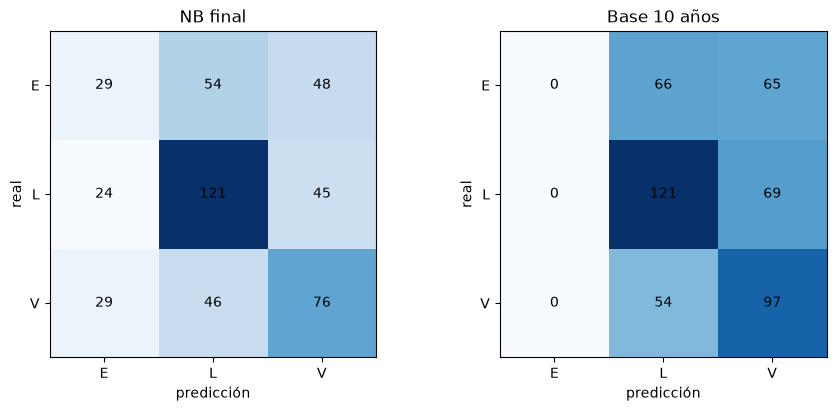

In [18]:
columnas_ampliadas = list(NUMERIC_FEATURES) + [
    'home_points_per_match_5', 'away_points_per_match_5',
    'home_goal_diff_per_match_5', 'away_goal_diff_per_match_5',
]
variantes_nb = {
    '6 tasas': list(NUMERIC_FEATURES),
    '+ puntos y diferencia de gol (10)': columnas_ampliadas,
}

# El mismo evaluador y los mismos cortes que en la selección de m:
# Cortes fijos solo para last_5. Cuantiles del train del fold para el resto.
validacion_atributos_nb = {
    nombre: evaluate_temporal_cv(
        MEstimateCategoricalNB(m=nb_m, min_categories=4), train, folds,
        'discrete', feature_columns=columnas)
    for nombre, columnas in variantes_nb.items()
}
comparacion_cols = pd.DataFrame([
    {'atributos': nombre, 'n_atributos': len(columnas),
     'macro_f1_validacion': validacion_atributos_nb[nombre].macro_f1.mean()}
    for nombre, columnas in variantes_nb.items()
])
display(comparacion_cols.round(6))
folds_6 = validacion_atributos_nb['6 tasas'].macro_f1.tolist()
folds_10 = validacion_atributos_nb[
    '+ puntos y diferencia de gol (10)'].macro_f1.tolist()
print('Macro-F1 anual, 10 atributos (2021/2022/2023):',
      ', '.join(f'{v:.4f}' for v in folds_10))


def seleccionar_columnas_nb(comparacion, variantes):
    """Maximiza macro-F1. Ante empate conserva el conjunto más pequeño."""
    elegida = comparacion.sort_values(
        ['macro_f1_validacion', 'n_atributos'],
        ascending=[False, True], kind='stable').iloc[0]['atributos']
    return elegida, list(variantes[elegida])


usar_final, columnas_final = seleccionar_columnas_nb(comparacion_cols, variantes_nb)
print('Variante elegida:', usar_final)
display(validacion_atributos_nb[usar_final][['validacion', 'macro_f1']])

# La selección determina las entradas de ambos NB y del discretizador final.
disc_final = new_discretizer(columnas_final)
disc_final.fit(train[columnas_final])
Xnb_train = disc_final.transform(train[columnas_final])
Xnb_test = disc_final.transform(test[columnas_final])

nb_final = MEstimateCategoricalNB(m=nb_m, min_categories=4).fit(
    Xnb_train, train['winner'])
nb_ref = CategoricalNB(alpha=nb_m / 4, min_categories=4, force_alpha=True).fit(
    Xnb_train, train['winner'])

pred_nb = nb_final.predict(Xnb_test)
pred_ref = nb_ref.predict(Xnb_test)
print('Same predictions (propio vs CategoricalNB):',
      bool((pred_nb == pred_ref).all()))
log_propio = nb_final._joint_log_likelihood(Xnb_test)
log_ref = nb_ref._joint_log_likelihood(Xnb_test)
print('Max |log-score| dif (propio vs CategoricalNB):',
      f'{float(np.max(np.abs(log_propio - log_ref))):.3e}')
nb_ok = pred_nb == y_test
base_ok = pred_base == y_test
print('NB y baseline aciertan en común:', int((nb_ok & base_ok).sum()))
print('NB y baseline fallan en común:', int((~nb_ok & ~base_ok).sum()))
print('NB corrige errores del baseline:', int((~base_ok & nb_ok).sum()))
print('NB pierde aciertos del baseline:', int((base_ok & ~nb_ok).sum()))
print('Máxima diferencia absoluta de probabilidades NB:',
      np.max(np.abs(nb_final.predict_proba(Xnb_test)
                    - nb_ref.predict_proba(Xnb_test))))
print('Accuracy NB:', round(accuracy_score(y_test, pred_nb), 4))
print('Macro-F1 NB:', round(
    f1_score(y_test, pred_nb, average='macro', zero_division=0), 4))
reporte_por_clases(f'NB propio ({len(columnas_final)} atributos)', y_test, pred_nb)

fig, ejes = plt.subplots(1, 2, figsize=(9, 4), layout='constrained')
for eje, (nombre, pred) in zip(ejes, [('NB final', pred_nb),
                                      ('Base 10 años', pred_base)]):
    matriz = confusion_matrix(y_test, pred, labels=CLASSES)
    eje.imshow(matriz, cmap='Blues')
    eje.set(xticks=range(3), xticklabels=CLASSES,
            yticks=range(3), yticklabels=CLASSES,
            xlabel='predicción', ylabel='real', title=nombre)
    for fila in range(3):
        for col in range(3):
            eje.text(col, fila, str(matriz[fila, col]),
                     ha='center', va='center')
plt.show()

Los dos NB coinciden en las 472 predicciones: aciertan 226 partidos
(accuracy 0.4788, macro-F1 0.4454), frente a 218 del baseline
(0.4619 y 0.3564). NB reconoce 121 de los 190 resultados `L`, 29 de los
131 empates y 76 de los 151 `V`. El baseline reconoce 121 `L` y 97 `V`
y nunca predice empate. Son ocho aciertos adicionales, con una mejora de
macro-F1 que no es uniforme: NB gana en E y L, pero pierde en V.


## 14. Efectividad del algoritmo

Juntamos todo en una tabla sobre el mismo test y lo comparamos con la regla
trivial de predecir siempre L (la clase mayoritaria). Además vemos cuántos
empates captura cada modelo.

In [19]:
siempre_l = np.full(len(y_test), 'L')
filas_resumen = filas_comp + [
    {'modelo': f'NB propio ({len(columnas_final)} atributos)',
     'accuracy': round(accuracy_score(y_test, pred_nb), 4),
     'macro_f1': round(
         f1_score(y_test, pred_nb, average='macro', zero_division=0), 4)},
    {'modelo': 'Naive Bayes (sklearn)',
     'accuracy': round(accuracy_score(y_test, pred_ref), 4),
     'macro_f1': round(
         f1_score(y_test, pred_ref, average='macro', zero_division=0), 4)},
    {'modelo': 'Siempre L',
     'accuracy': round(accuracy_score(y_test, siempre_l), 4),
     'macro_f1': round(
         f1_score(y_test, siempre_l, average='macro', zero_division=0), 4)},
]
resumen = pd.DataFrame(filas_resumen)
display(resumen.sort_values('accuracy', ascending=False).reset_index(drop=True))

print('Empates reales en test:', int((y_test == 'E').sum()),
      'de', len(y_test))
for nombre, pred in [('ID3', y_pred), ('NB final', pred_nb),
                     ('Base 10 años', pred_base)]:
    print(f'{nombre:<15} predijo E en '
          f'{int((pred == "E").sum())} partidos '
          f'(acierto {(pred[y_test == "E"] == "E").mean():.1%} de los reales)')

,modelo,accuracy,macro_f1
0,NB propio (10 atributos),0.4788,0.4454
1,Naive Bayes (sklearn),0.4788,0.4454
2,sklearn DT (mismo input),0.4682,0.4109
3,ID3 propio,0.4661,0.4027
4,Base 10 años (clasificador base),0.4619,0.3564
5,sklearn RandomForest (tasas crudas),0.4258,0.4219
6,Siempre L,0.4025,0.1913
7,sklearn DT (tasas crudas),0.3602,0.3531


Empates reales en test: 131 de 472
ID3             predijo E en 56 partidos (acierto 13.7% de los reales)
NB final        predijo E en 82 partidos (acierto 22.1% de los reales)
Base 10 años    predijo E en 0 partidos (acierto 0.0% de los reales)


### 14.1. Métricas por clase de los seis modelos

La misma función `reporte_por_clases` (definiciones en la sección 7) mide a
los seis modelos sobre el mismo test, uno detrás del otro, para comparar
directamente cómo trata cada clase: el ID3 propio, el NB propio, el baseline
de diez años, el árbol de scikit-learn sobre códigos, el Random Forest y el
árbol sobre tasas crudas. El `CategoricalNB` de scikit-learn no se repite acá
porque sus predicciones son idénticas a las del NB propio (sección 13).


In [20]:
reporte_por_clases('ID3 propio', y_test, y_pred)
reporte_por_clases(f'NB propio ({len(columnas_final)} atributos)', y_test, pred_nb)
reporte_por_clases('Base 10 años', y_test, pred_base)
reporte_por_clases('sklearn DT (mismo input)', y_test,
                   predicciones_comp['sklearn DT (mismo input)'])
reporte_por_clases('sklearn RandomForest (tasas crudas)', y_test,
                   predicciones_comp['sklearn RandomForest (tasas crudas)'])
reporte_por_clases('sklearn DT (tasas crudas)', y_test,
                   predicciones_comp['sklearn DT (tasas crudas)'])

# Matrices de confusión impresas (filas real, columnas predichas E/L/V).
for nombre, pred in [
    ('DT códigos', predicciones_comp['sklearn DT (mismo input)']),
    ('Random Forest', predicciones_comp['sklearn RandomForest (tasas crudas)']),
    ('DT crudas', predicciones_comp['sklearn DT (tasas crudas)']),
]:
    m = confusion_matrix(y_test, pred, labels=CLASSES)
    print(f'\n{nombre}: aciertos {int(m.diagonal().sum())} / {len(y_test)}, '
          f'predichos E {int((pred == "E").sum())}')
    print(m)

### ID3 propio
              precision    recall  f1-score   support

           E     0.3214    0.1374    0.1925       131
           L     0.4757    0.7737    0.5892       190
           V     0.5140    0.3642    0.4264       151

    accuracy                         0.4661       472
   macro avg     0.4371    0.4251    0.4027       472
weighted avg     0.4452    0.4661    0.4270       472

### NB propio (10 atributos)
              precision    recall  f1-score   support

           E     0.3537    0.2214    0.2723       131
           L     0.5475    0.6368    0.5888       190
           V     0.4497    0.5033    0.4750       151

    accuracy                         0.4788       472
   macro avg     0.4503    0.4538    0.4454       472
weighted avg     0.4624    0.4788    0.4646       472

### Base 10 años
              precision    recall  f1-score   support

           E     0.0000    0.0000    0.0000       131
           L     0.5021    0.6368    0.5615       190
           V  

### 14.2. Ejemplos de la matriz de confusión del NB

La matriz de confusión resume 472 partidos en nueve conteos. Esta tabla da
cara a cada conteo. Ordenamos el test por fecha, local y visitante y tomamos
el primer partido de cada par (resultado real, predicción del NB), cubriendo
así las nueve celdas posibles: el primer empate que el NB acierta, el primer
empate que predice donde no lo hubo, el primer local que clasifica mal, etc.
Cada fila trae el marcador real (leído del ZIP limpio, nunca usado como
atributo) y la predicción del NB y del baseline.

Es la tabla que alimenta el apartado ``Análisis cualitativo'' del informe:
los ejemplos citados allí salen de acá. Es ilustrativa, no representativa:
muestra un caso por celda, no la frecuencia de cada una.

In [21]:
goles = matches[["date", "home", "away", "gh", "ga"]].copy()
cuali = test[["date", "home", "away", "winner"]].merge(
    goles, on=["date", "home", "away"], how="left", validate="one_to_one")
assert cuali is not None and cuali["gh"].notna().all()
cuali["pred_nb"] = pred_nb
cuali["pred_base"] = pred_base
cuali["marcador"] = (cuali["gh"].astype(int).astype(str) + "-"
                     + cuali["ga"].astype(int).astype(str))
cuali = cuali.sort_values(["date", "home", "away"],
                          kind="mergesort").reset_index(drop=True)
primeros = cuali.drop_duplicates(["winner", "pred_nb"], keep="first")
display(primeros[["date", "home", "away", "marcador", "winner",
                  "pred_nb", "pred_base"]])

,date,home,away,marcador,winner,pred_nb,pred_base
0,2024-02-17,CA Fenix,Danubio,1-2,V,V,V
2,2024-02-17,Nacional,River Plate,2-1,L,L,L
3,2024-02-18,CA Cerro,Montevideo Wanderers,1-1,E,V,V
4,2024-02-18,Deportivo Maldonado,Boston River,1-2,V,L,L
9,2024-02-24,Montevideo Wanderers,Racing Club,0-1,V,E,L
11,2024-02-25,Cerro Largo FC,CA Fenix,0-0,E,L,L
17,2024-03-02,River Plate,Danubio,1-0,L,V,L
29,2024-03-11,Montevideo Wanderers,Deportivo Maldonado,0-0,E,E,L
52,2024-04-07,CA Cerro,Rampla Juniors Futbol Club,3-0,L,E,L


### 14.3. Diagnóstico por ventaja local

Dividimos todo el test según el signo de la diferencia de puntos por partido
en los últimos cinco antecedentes de cada equipo. Es un diagnóstico posterior
a la evaluación, sin búsqueda de umbrales: queremos ver si el NB acierta más
cuando el local llega con ventaja histórica.


In [22]:
ventaja = np.sign(
    test['home_points_per_match_5'].to_numpy()
    - test['away_points_per_match_5'].to_numpy())
etiquetas = {1: 'ventaja local', 0: 'igualdad', -1: 'ventaja visitante'}
for signo in (1, 0, -1):
    mask = ventaja == signo
    n = int(mask.sum())
    nb_h = int((pred_nb[mask] == y_test[mask]).sum())
    base_h = int((pred_base[mask] == y_test[mask]).sum())
    comp = (pd.Series(y_test[mask]).value_counts()
            .reindex(CLASSES).fillna(0).astype(int))
    mf = f1_score(y_test[mask], pred_nb[mask], labels=CLASSES,
                  average='macro', zero_division=0)
    print(f'{etiquetas[signo]}: NB {nb_h}/{n} ({100 * nb_h / n:.2f}%), '
          f'baseline {base_h}, '
          f'clases E/L/V {comp["E"]}/{comp["L"]}/{comp["V"]}, '
          f'macro-F1 NB {mf:.4f}')

ventaja local: NB 116/216 (53.70%), baseline 99, clases E/L/V 62/106/48, macro-F1 NB 0.3788
igualdad: NB 15/39 (38.46%), baseline 21, clases E/L/V 9/15/15, macro-F1 NB 0.3737
ventaja visitante: NB 95/217 (43.78%), baseline 98, clases E/L/V 60/69/88, macro-F1 NB 0.3741


## 15. Cómo interpretar los resultados

1. Predecir siempre L alcanza accuracy 0.4025. NB obtiene 0.4788 frente a 0.4619 del baseline de diez años, ocho aciertos adicionales, y macro-F1 0.4454 frente a 0.3564. La mejora es modesta y no uniforme entre clases.
2. Los empates son la clase más difícil. Son ~28% de los datos y ningún modelo los reconoce bien: el recall de E es 0% para la base, 13.7% para el ID3 propio, 16.0% para el árbol de sklearn sobre códigos, 22.1% para los dos NB, 25.9% para el árbol de tasas crudas y 35.9% para el Random Forest. No hay un rango angosto "17% a 22%": el recall va de 0% a 35.9% según el modelo, y solo el bosque y el árbol de tasas crudas pasan del 23%. Las tasas de victoria no discriminan empates, que quedan diluidos en las hojas/nodos que eligen la opción de menor riesgo. En contraste, la precisión de L es alta: cuando el modelo dice L acierta bastante. El problema es que predice L de más y se pierde empates.
3. Tres atributos concentran casi toda la ganancia: la forma de los últimos cinco partidos y el historial local. La poda con `min_info_gain` actúa: sin poda el árbol crece hasta ~645 hojas (memoriza ruido). El umbral elegido baja a ~589 hojas con el mejor macro-F1 de validación, y al subir más el umbral (0.02+) el macro-F1 colapsa porque el árbol ya no separa ni las clases grandes.
4. Ambos NB alcanzan el mayor accuracy (0.4788) y macro-F1 (0.4454) de esta comparación. ID3 obtiene 0.4661/0.4027, el árbol sklearn sobre códigos 0.4682/0.4109 y el bosque 0.4258/0.4219. El resultado describe estos 472 partidos. No demuestra superioridad general ni significación estadística.
5. La selección automática usa validación temporal de 2021-2023. El bloque de test de 2024-2025 ya había sido inspeccionado en versiones anteriores. Esta corrección de consistencia no constituye una evaluación confirmatoria sobre un holdout intacto. Los históricos usan solo fechas anteriores y 2025 llega hasta junio.
